In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib

import pickle
import time
import memory_profiler

%load_ext memory_profiler

from pathlib import Path
import distro

%load_ext watermark

In [ ]:
%load_ext IPython.extensions.autoreload
%autoreload 2

# from llm_readability.word_len import create_word_length_analysis_plots

/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:82: SyntaxWarning: invalid escape sequence '\s'
  "\s*For complete details on the use and execution of this protocol.*": "",
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:85: SyntaxWarning: invalid escape sequence '\.'
  "For further information please consult linked data\.*": "",
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:87: SyntaxWarning: invalid escape sequence '\s'
  "Communicated by": {"\s*\(?Communicated by.{0,100}$": ""},
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:88: SyntaxWarning: invalid escape sequence '\.'
  "Graphical abstract": {"\.\s*Graphical abstract.*": "."},
/gpfs01/berens/user/rgonzalesmarquez/phd/llm-readability/src/llm_readability/word_len.py:89: SyntaxWarning: invalid escape sequence '\.'
  "GRAPHICAL ABSTRACT": {"\.\s*GRAPHICAL ABSTRACT.*": 

In [ ]:
import black
import jupyter_black

jupyter_black.load(line_length=79)

In [ ]:
variables_path = Path("../results/variables")
figures_path = Path("../results/figures/tmp")
data_path = Path("../data")
berenslab_data_path = Path("/gpfs01/berens/data/data/pubmed_processed/")

In [ ]:
figures_path.exists()

True

In [ ]:
plt.style.use("matplotlib_style.txt")

In [ ]:
%watermark -a 'Rita González-Márquez' -t -d -tz -u -v -iv -w -m -h -p transformers -p openTSNE
print(distro.name(pretty=True))

Author: Rita González-Márquez

Last updated: 2025-07-25 14:53:19CEST

Python implementation: CPython
Python version       : 3.12.9
IPython version      : 9.4.0

openTSNE: not installed

Compiler    : Clang 19.1.6 
OS          : Linux
Release     : 4.18.0-553.el8_10.x86_64
Machine     : x86_64
Processor   : x86_64
CPU cores   : 64
Architecture: 64bit

Hostname: gber7

jupyter_black  : 0.4.0
black          : 25.1.0
matplotlib     : 3.10.3
pathlib        : 1.0.1
memory_profiler: 0.61.0
distro         : 1.9.0
numpy          : 2.2.6
llm_readability: 0.1.0
pandas         : 2.3.1

Watermark: 2.5.0

Rocky Linux 8.10 (Green Obsidian)


# Word counts

## Load results

In [ ]:
pickle_in = open(variables_path / "results_word_len.pkl", "rb")
results_word_len = pickle.load(pickle_in)

In [ ]:
results_word_len

{'years': array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024, 2025]),
 'word_lengths': array([1, 2, 3, ..., 3, 3, 3], shape=(294234,)),
 'count_matrix': array([[2110448, 2273315, 2491466, ..., 4559278, 4905555, 3054205],
        [   6416,    7277,    8053, ...,   13343,   13945,    8656],
        [   1739,    1780,    2330, ...,    3239,    3688,    2625],
        ...,
        [      0,       0,       6, ...,       4,       1,       8],
        [      4,       0,       2, ...,       1,       9,       3],
        [      8,      12,       0, ...,      15,       4,       7]],
       shape=(294234, 16)),
 'length_distribution': {},
 'mean_length': array([5.59099471, 5.59630041, 5.59902747, 5.61077897, 5.61788641,
        5.62244967, 5.62916711, 5.64030299, 5.64086329, 5.64276489,
        5.64336838, 5.64908615, 5.65211557, 5.67057112, 5.73548867,
        5.81730133]),
 'median_length': array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5

In [ ]:
np.arange(0, 38)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37])

In [ ]:
for year in np.arange(2010, 2026):
    print(year)
    print(results_word_len["length_category_counts"][str(year)]["lengths"])
    # results_word_len["length_category_counts"][str(year)]["lengths"] = (
    #     np.arange(0, 38)
    # )  # 37 is max
    # print(results_word_len["length_category_counts"][str(year)]["lengths"])

2010
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2011
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2012
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2013
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2014
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2015
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2016
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2017
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37]
2018
[ 0  1  2  3  4  5 

In [ ]:
f = open(variables_path / "results_word_len.pkl", "wb")
pickle.dump(results_word_len, f)
f.close()

## Plots

0.16518575695748527


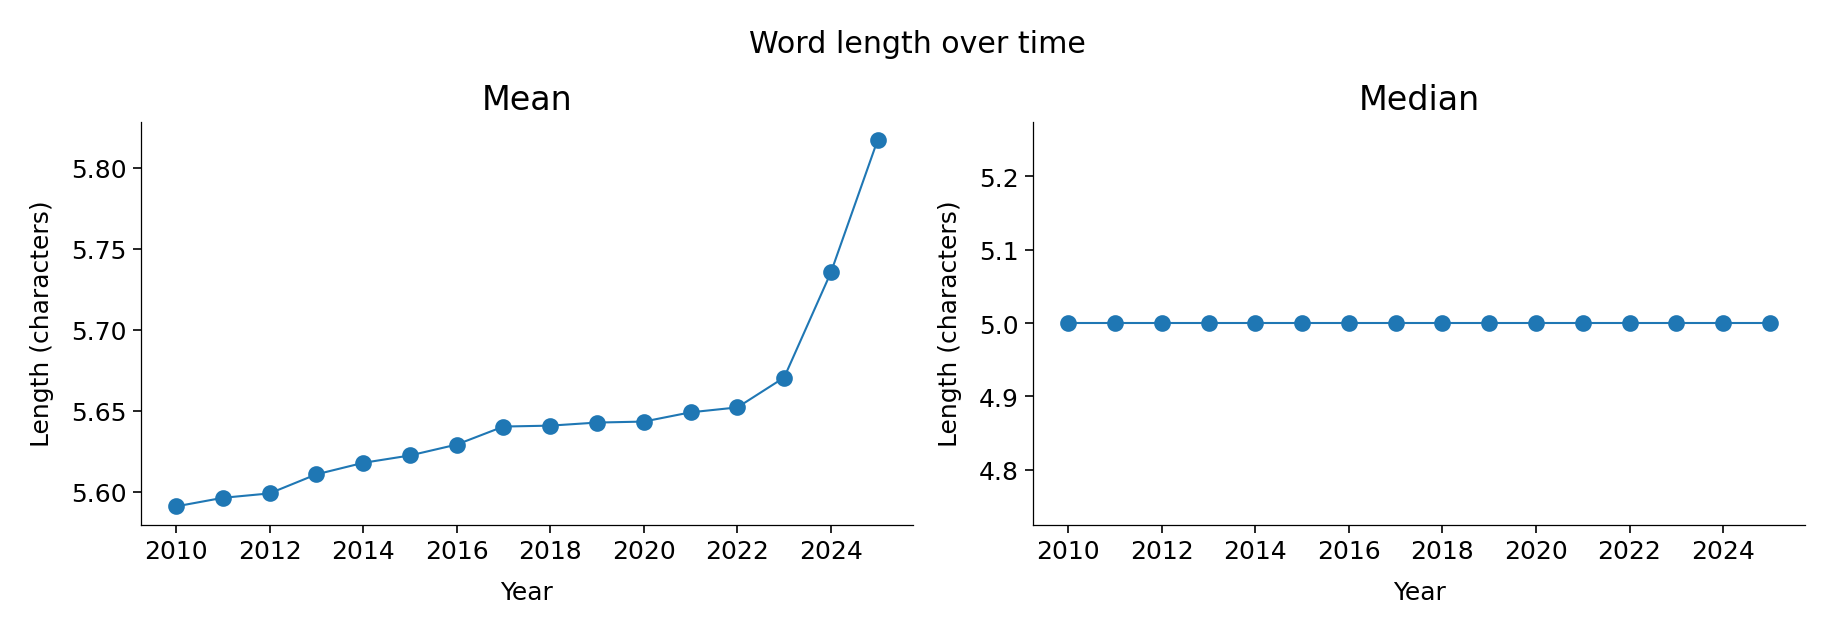

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2))
fig.suptitle("Word length over time")  # , fontsize=16, fontweight="bold")

years = results_word_len["years"]

# Mean
axes[0].plot(
    years,
    results_word_len["mean_length"],
    marker=".",
    # linewidth=2,
    label="Mean",
)
print(
    results_word_len["mean_length"][-1] - results_word_len["mean_length"][-4]
)
# axes[0].fill_between(
#     years,
#     results_word_len["mean_length"] - results_word_len["std_length"],
#     results_word_len["mean_length"] + results_word_len["std_length"],
#     alpha=0.3,
#     # label="±1 STD",
# )

axes[0].set_title("Mean")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Length (characters)")

# Median
axes[1].plot(
    years, results_word_len["median_length"], label="Median", marker="."
)
axes[1].set_title("Median")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Length (characters)")

fig.savefig(figures_path / "word_length_over_time.png")

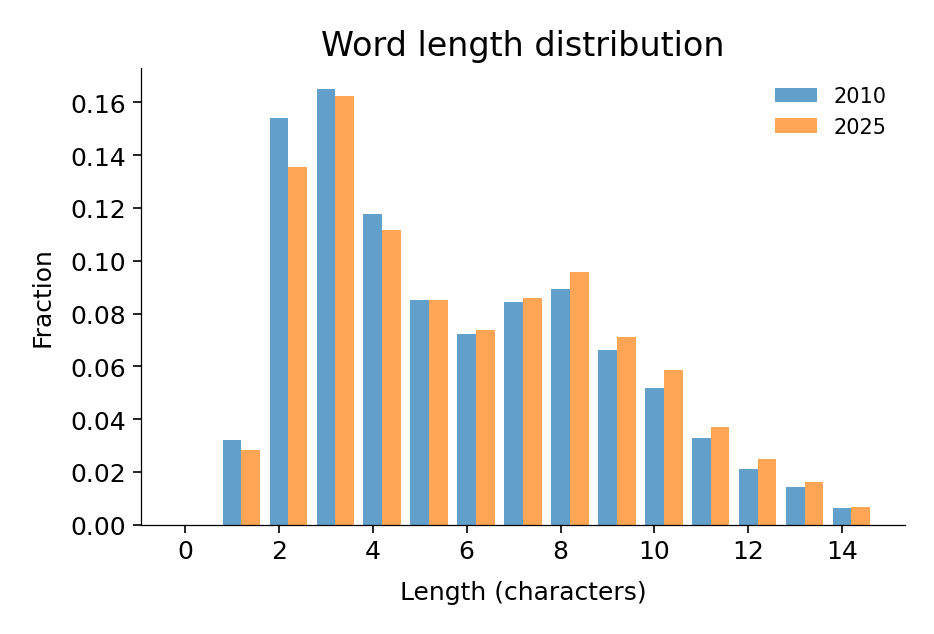

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


# first_year = str(2022)
first_year = str(2010)
last_year = str(2022)
last_year = str(2025)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

axes.bar(
    first_data["lengths"][:15],
    first_data["proportions"][:15],
    alpha=0.7,
    label=first_year,
    width=0.4,
)
axes.bar(
    last_data["lengths"][:15] + 0.4,
    last_data["proportions"][:15],
    alpha=0.7,
    label=last_year,
    width=0.4,
)
axes.set_title(f"Word length distribution")  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel("Fraction")
axes.legend()

fig.savefig(
    figures_path / f"word_length_distribution_{first_year}_vs_{last_year}.png"
)

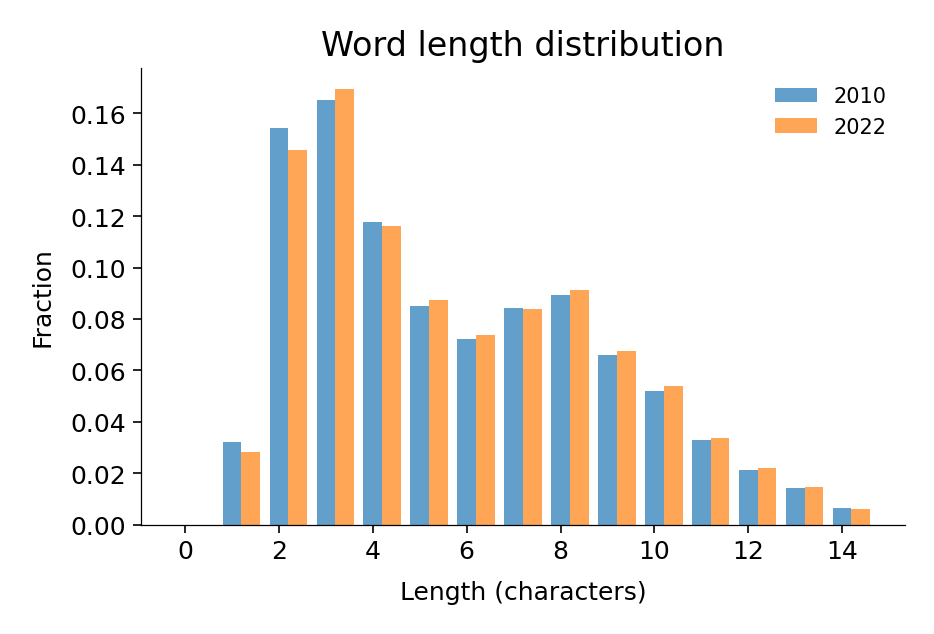

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


# first_year = str(2022)
first_year = str(2010)
last_year = str(2022)
# last_year = str(2025)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

axes.bar(
    first_data["lengths"][:15],
    first_data["proportions"][:15],
    alpha=0.7,
    label=first_year,
    width=0.4,
)
axes.bar(
    last_data["lengths"][:15] + 0.4,
    last_data["proportions"][:15],
    alpha=0.7,
    label=last_year,
    width=0.4,
)
axes.set_title(f"Word length distribution")  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel("Fraction")
axes.legend()

fig.savefig(
    figures_path / f"word_length_distribution_{first_year}_vs_{last_year}.png"
)

/tmp/ipykernel_231994/2619165526.py:11: RuntimeWarning: invalid value encountered in divide
  ratio = last_data["proportions"][:15] / first_data["proportions"][:15]
/tmp/ipykernel_231994/2619165526.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


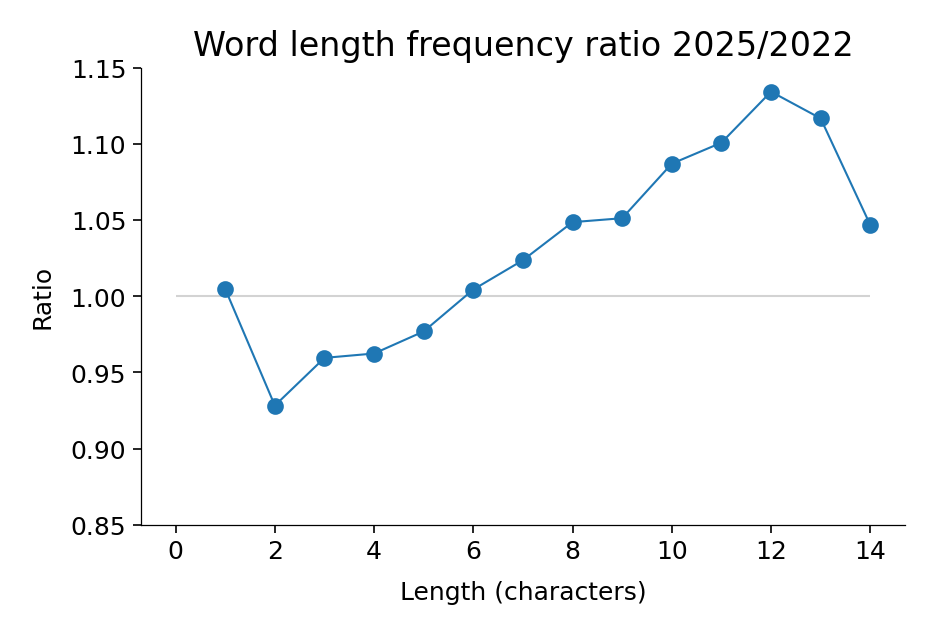

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


# first_year = str(2010)
first_year = str(2022)
# last_year = str(2022)
last_year = str(2025)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

ratio = last_data["proportions"][:15] / first_data["proportions"][:15]
axes.hlines(
    1,
    first_data["lengths"][:15][0],
    first_data["lengths"][:15][-1],
    color="lightgrey",
)
axes.plot(
    first_data["lengths"][:15],
    ratio,
    marker=".",
    # linewidth=2,
)
axes.set_title(
    f"Word length frequency ratio {last_year}/{first_year}"
)  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel(f"Ratio")
axes.set_ylim(0.85, 1.15)
axes.legend()

fig.savefig(
    figures_path / f"word_length_frequency_ratio_{last_year}_{first_year}.png"
)

# Excluding words under 3 characters

## Load results

In [ ]:
pickle_in = open(
    variables_path / "exclude_2_3_char/results_word_len.pkl", "rb"
)
results_word_len = pickle.load(pickle_in)

In [ ]:
results_word_len

{'years': array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020,
        2021, 2022, 2023, 2024, 2025]),
 'word_lengths': array([4, 5, 5, ..., 5, 4, 5], shape=(280706,)),
 'count_matrix': array([[ 8, 23, 21, ..., 12, 15,  3],
        [ 3,  7,  2, ...,  0,  0,  2],
        [ 1,  0,  0, ...,  2,  5,  0],
        ...,
        [63, 71, 64, ..., 47, 44, 26],
        [ 0,  0,  0, ..., 19, 38, 38],
        [ 0,  0,  7, ...,  0, 13,  7]], shape=(280706, 16)),
 'length_distribution': {},
 'mean_length': array([7.33019494, 7.33373761, 7.33262059, 7.3341773 , 7.33576626,
        7.33745197, 7.33921062, 7.34470865, 7.3458755 , 7.34761475,
        7.34465414, 7.34508147, 7.34617328, 7.36314443, 7.41616627,
        7.46521108]),
 'median_length': array([7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7., 7.]),
 'std_length': array([2.69456413, 2.69412337, 2.69232238, 2.69142824, 2.68932339,
        2.68825158, 2.68640109, 2.68641004, 2.68551925, 2.68475084,
        2.681614

## Plots

0.11903779882680965


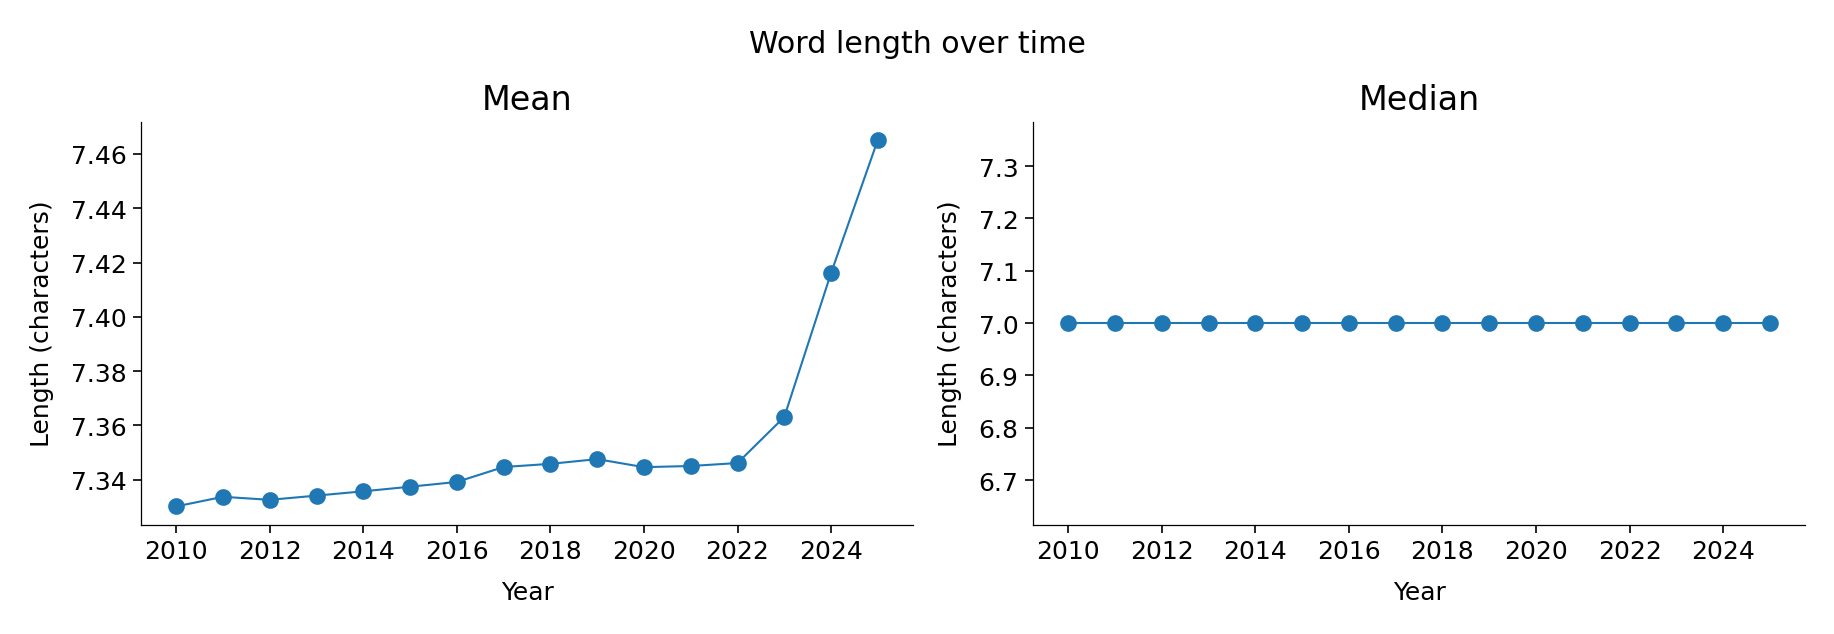

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6, 2))
fig.suptitle("Word length over time")  # , fontsize=16, fontweight="bold")

years = results_word_len["years"]

# Mean
axes[0].plot(
    years,
    results_word_len["mean_length"],
    marker=".",
    # linewidth=2,
    label="Mean",
)
print(
    results_word_len["mean_length"][-1] - results_word_len["mean_length"][-4]
)
# axes[0].fill_between(
#     years,
#     results_word_len["mean_length"] - results_word_len["std_length"],
#     results_word_len["mean_length"] + results_word_len["std_length"],
#     alpha=0.3,
#     # label="±1 STD",
# )

axes[0].set_title("Mean")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Length (characters)")

# Median
axes[1].plot(
    years, results_word_len["median_length"], label="Median", marker="."
)
axes[1].set_title("Median")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Length (characters)")

fig.savefig(figures_path / "word_length_over_time_length_threshold_3.png")

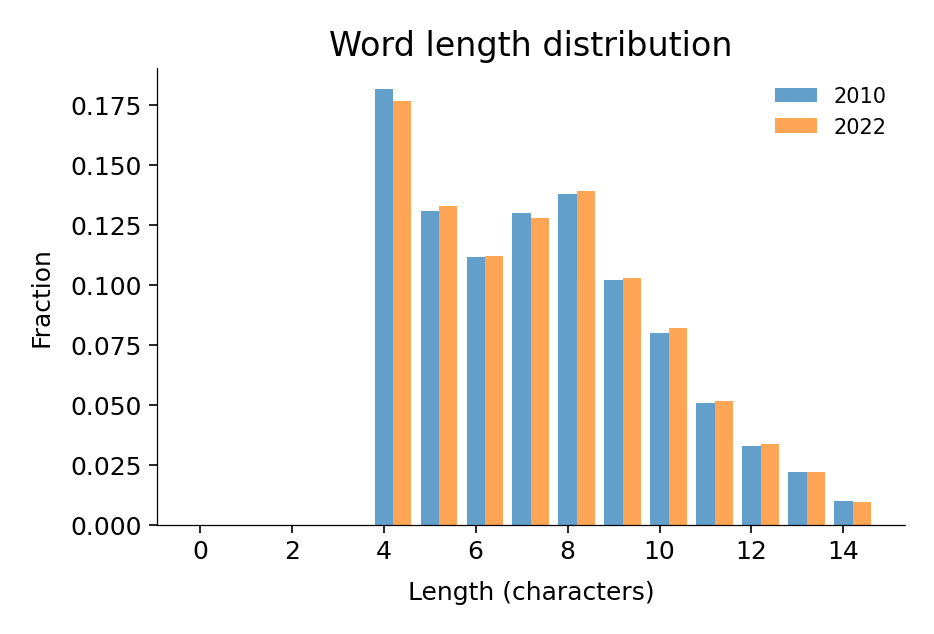

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


# first_year = str(2022)
first_year = str(2010)
last_year = str(2022)
# last_year = str(2025)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

axes.bar(
    first_data["lengths"][:15],
    first_data["proportions"][:15],
    alpha=0.7,
    label=first_year,
    width=0.4,
)
axes.bar(
    last_data["lengths"][:15] + 0.4,
    last_data["proportions"][:15],
    alpha=0.7,
    label=last_year,
    width=0.4,
)
axes.set_title(f"Word length distribution")  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel("Fraction")
axes.legend()

fig.savefig(
    figures_path
    / f"word_length_distribution_{first_year}_vs_{last_year}_length_threshold_3.png"
)

/tmp/ipykernel_231994/2329939696.py:11: RuntimeWarning: invalid value encountered in divide
  ratio = last_data["proportions"][:15] / first_data["proportions"][:15]
/tmp/ipykernel_231994/2329939696.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes.legend()


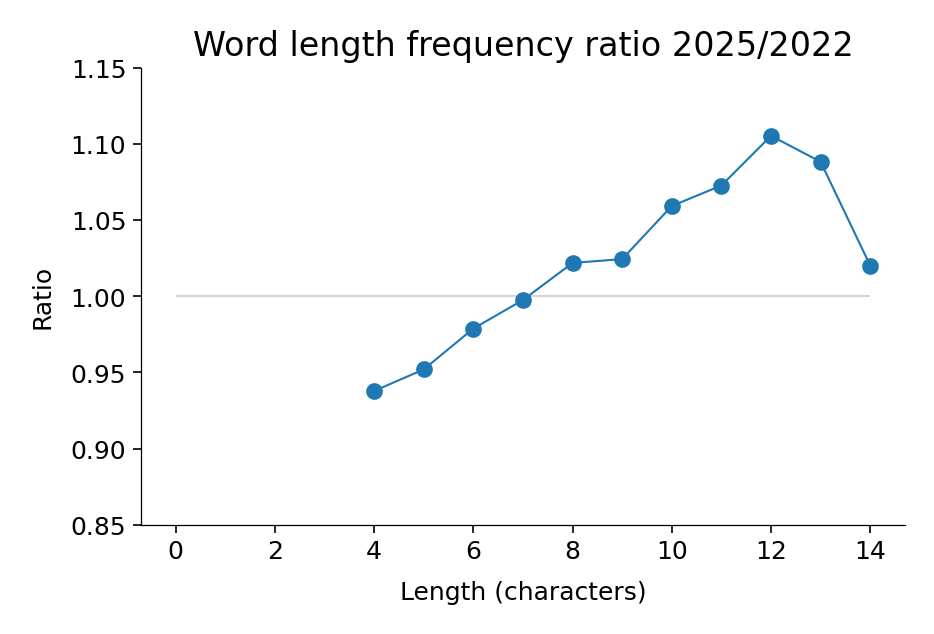

In [ ]:
fig, axes = plt.subplots(figsize=(3, 2))


# first_year = str(2010)
first_year = str(2022)
# last_year = str(2022)
last_year = str(2025)
first_data = results_word_len["length_category_counts"][first_year]
last_data = results_word_len["length_category_counts"][last_year]

ratio = last_data["proportions"][:15] / first_data["proportions"][:15]
axes.hlines(
    1,
    first_data["lengths"][:15][0],
    first_data["lengths"][:15][-1],
    color="lightgrey",
)
axes.plot(
    first_data["lengths"][:15],
    ratio,
    marker=".",
    # linewidth=2,
)
axes.set_title(
    f"Word length frequency ratio {last_year}/{first_year}"
)  #: {first_year} vs {last_year}")
axes.set_xlabel("Length (characters)")
axes.set_ylabel(f"Ratio")
axes.set_ylim(0.85, 1.15)
axes.legend()

fig.savefig(
    figures_path
    / f"word_length_frequency_ratio_{last_year}_{first_year}_length_threshold_3.png"
)